In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim


In [2]:
X, y = load_wine(return_X_y=True)

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))


Dataset shape: (178, 13)
Number of classes: 3


In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (124, 13)
Validation: (27, 13)
Test: (27, 13)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

In [6]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out


In [7]:
input_size = 13
hidden_size = 64
num_classes = 3
learning_rate = 0.001

model = MLP(input_size, hidden_size, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [8]:
num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)
        val_losses.append(val_loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {loss.item():.4f}, "
              f"Val Loss: {val_loss.item():.4f}")


Epoch [10/100], Train Loss: 0.9219, Val Loss: 0.9064
Epoch [20/100], Train Loss: 0.7219, Val Loss: 0.6919
Epoch [30/100], Train Loss: 0.4852, Val Loss: 0.4512
Epoch [40/100], Train Loss: 0.2767, Val Loss: 0.2597
Epoch [50/100], Train Loss: 0.1473, Val Loss: 0.1547
Epoch [60/100], Train Loss: 0.0821, Val Loss: 0.1033
Epoch [70/100], Train Loss: 0.0497, Val Loss: 0.0772
Epoch [80/100], Train Loss: 0.0327, Val Loss: 0.0639
Epoch [90/100], Train Loss: 0.0230, Val Loss: 0.0563
Epoch [100/100], Train Loss: 0.0171, Val Loss: 0.0514


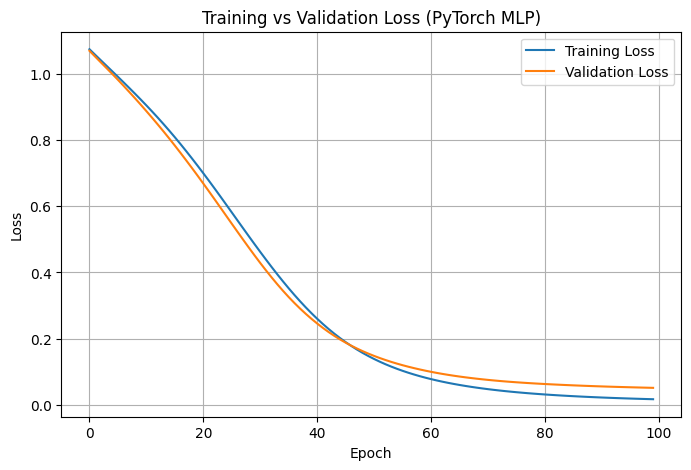

In [9]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (PyTorch MLP)")
plt.legend()
plt.grid()
plt.show()


In [10]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    _, y_test_pred = torch.max(test_outputs, 1)

test_accuracy = (y_test_pred == y_test_t).float().mean()
print("Test Accuracy:", test_accuracy.item())


Test Accuracy: 0.9629629850387573


In [11]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred.numpy()))

cm = confusion_matrix(y_test, y_test_pred.numpy())
print("Confusion Matrix:\n", cm)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.92      1.00      0.96        11
           2       1.00      0.86      0.92         7

    accuracy                           0.96        27
   macro avg       0.97      0.95      0.96        27
weighted avg       0.97      0.96      0.96        27

Confusion Matrix:
 [[ 9  0  0]
 [ 0 11  0]
 [ 0  1  6]]
